In [4]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
# Definir las columnas que nos interesan
columnas_a_usar = [
    'codigo_contrato', 'proveedor', 'titulo_contrato', 
    'tipo_contratacion', 'tipo_expediente', 'importe', 
    'moneda', 'fecha_inicio', 'fecha_fin'
]

print("⚠️ Cargando archivo de 907 MB. Esto puede tardar unos segundos...")

# Cargar solo las columnas que nos sirven
df = pd.read_csv(
    'compranet_historico.csv', 
    usecols=columnas_a_usar,
    parse_dates=['fecha_inicio', 'fecha_fin'],
    low_memory=False

)

print("✅ Archivo cargado correctamente.")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
df.head()

⚠️ Cargando archivo de 907 MB. Esto puede tardar unos segundos...
✅ Archivo cargado correctamente.
Filas: 2356609 | Columnas: 9


,codigo_contrato,proveedor,titulo_contrato,tipo_contratacion,tipo_expediente,importe,moneda,fecha_inicio,fecha_fin
0,2376191,Equity Appraisal Specialists Sa de Cv,Servicios Profesionales Para la Elaboración de...,Servicios,05. Adjudicación Directa LAASSP,89012.00,MXN,2020-07-22 05:00:00.000000 +00:00,2020-08-27 04:59:00.000000 +00:00
1,89,Si Vale Mexico Sa de Cv,Vales de Despensa de Fin de Año 2010,No especificado por la UC,V20151220 12. Adjudicación Directa Nacional Si...,5980292.70,MXN,2010-12-06 06:00:00.000000 +00:00,2011-01-01 05:59:00.000000 +00:00
2,1756,Metlife Mexico Sa de Cv,Seguros de Vida,No especificado por la UC,V20110525 01. Licitación Pública Nacional LAASSP,3904647.00,MXN,2011-01-01 06:00:00.000000 +00:00,2011-12-31 06:00:00.000000 +00:00
3,1761,"Hir Compañia de Seguros, S.A. de C.V.",Seguros de Vida,No especificado por la UC,V20110525 01. Licitación Pública Nacional LAASSP,45944.34,MXN,2011-01-01 06:00:00.000000 +00:00,2011-12-31 06:00:00.000000 +00:00
4,1759,Metlife Mexico Sa de Cv,Seguros de Vida,No especificado por la UC,V20110525 01. Licitación Pública Nacional LAASSP,1685589.35,MXN,2011-01-01 06:00:00.000000 +00:00,2011-12-31 06:00:00.000000 +00:00


In [26]:
# Ver tipos de datos y nulos
print("📊 Información del dataset:")
df.info()

print("\n🔍 ¿Hay valores nulos en columnas críticas?")
print(df[['proveedor', 'importe', 'fecha_inicio']].isnull().sum())

print("\n💰 Estadísticas del campo 'importe':")
print(df['importe'].describe())

📊 Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 2356609 entries, 0 to 2356608
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   codigo_contrato    int64  
 1   proveedor          str    
 2   titulo_contrato    str    
 3   tipo_contratacion  str    
 4   tipo_expediente    str    
 5   importe            float64
 6   moneda             str    
 7   fecha_inicio       str    
 8   fecha_fin          str    
dtypes: float64(1), int64(1), str(7)
memory usage: 161.8 MB

🔍 ¿Hay valores nulos en columnas críticas?
proveedor          0
importe         5182
fecha_inicio       0
dtype: int64

💰 Estadísticas del campo 'importe':
count    2.351427e+06
mean     2.465576e+06
std      9.286537e+07
min      0.000000e+00
25%      3.986009e+04
50%      1.237158e+05
75%      4.769647e+05
max      8.482838e+10
Name: importe, dtype: float64


In [27]:
# 1. Limpieza de texto
df['proveedor'] = df['proveedor'].astype(str).str.strip().str.upper()

# 2. FORZAR la conversión de fecha_inicio a formato datetime
df['fecha_inicio'] = pd.to_datetime(df['fecha_inicio'], errors='coerce')

# 3. Extraer año y mes
df['año'] = df['fecha_inicio'].dt.year
df['mes'] = df['fecha_inicio'].dt.month

# 4. Filtrar solo contratos en pesos mexicanos (MXN)
df_mxn = df[df['moneda'] == 'MXN'].copy()

# KPI 1: Gasto total por año
gasto_anual = df_mxn.groupby('año')['importe'].sum().reset_index()
gasto_anual.columns = ['Año', 'Total_Gastado']

# KPI 2: Top 10 proveedores por monto total
top_proveedores = df_mxn.groupby('proveedor')['importe'].sum().nlargest(10).reset_index()
top_proveedores.columns = ['Proveedor', 'Monto_Total']

# KPI 3: Promedio de monto por contrato (por año)
promedio_anual = df_mxn.groupby('año')['importe'].mean().reset_index()
promedio_anual.columns = ['Año', 'Monto_Promedio']

# KPI 4: Conteo de contratos por año
contratos_anual = df_mxn.groupby('año')['codigo_contrato'].count().reset_index()
contratos_anual.columns = ['Año', 'Total_Contratos']

# 5. Guardar los KPIs en un solo archivo CSV (para Power BI)
kpis_final = gasto_anual.merge(promedio_anual, on='Año').merge(contratos_anual, on='Año')
kpis_final.to_csv('kpis_compranet.csv', index=False)

print("✅ KPIs calculados y guardados en 'kpis_compranet.csv'")
print("\n📈 Vista previa de los KPIs:")
print(kpis_final.head())

✅ KPIs calculados y guardados en 'kpis_compranet.csv'

📈 Vista previa de los KPIs:
      Año  Total_Gastado  Monto_Promedio  Total_Contratos
0  1900.0   6.893640e+04    6.893640e+04                1
1  2001.0   3.262095e+05    1.631048e+05                2
2  2002.0   8.100000e+04    4.050000e+04                2
3  2009.0   1.894655e+07    9.473277e+06                2
4  2010.0   1.146151e+10    2.344827e+06             4888


In [28]:
# Guardar el dataset limpio (solo columnas útiles)
df_limpio = df_mxn[['proveedor', 'titulo_contrato', 'tipo_contratacion', 'importe', 'año', 'mes']]
df_limpio.to_csv('compranet_limpio.csv', index=False)

print("✅ Archivo 'compranet_limpio.csv' guardado. ¡Listo para Power BI!")

✅ Archivo 'compranet_limpio.csv' guardado. ¡Listo para Power BI!


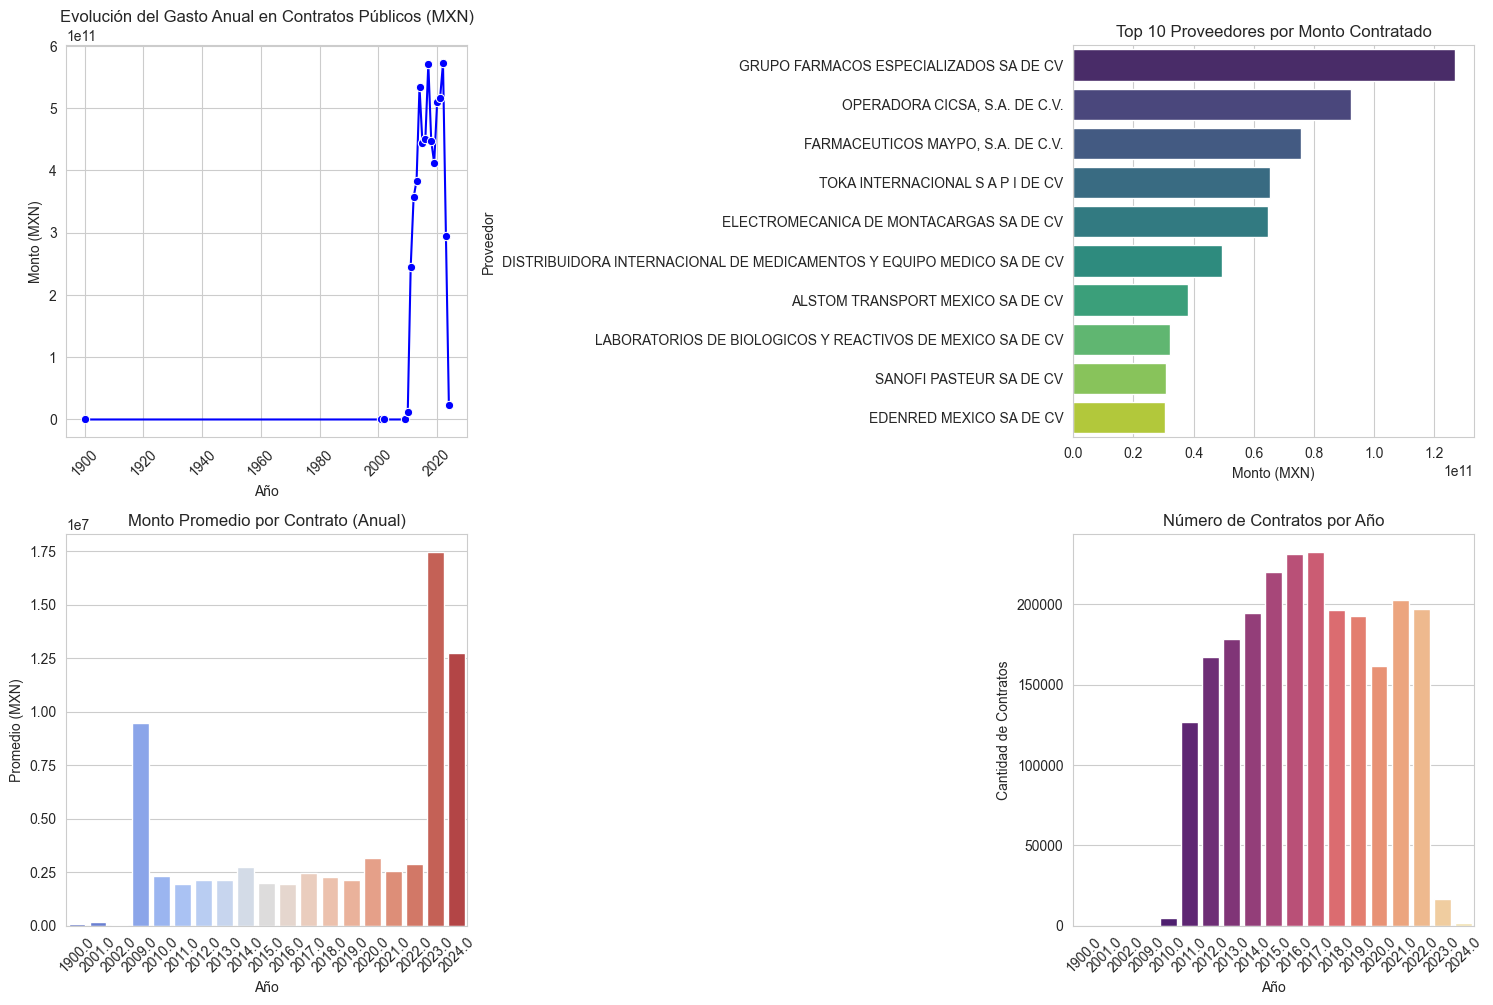

✅ Gráficos guardados en 'graficos_kpis.png'


In [29]:
# Configurar estilo de gráficos
sns.set_style("whitegrid")
plt.figure(figsize=(15, 10))

# Gráfico 1: Evolución del gasto anual
plt.subplot(2, 2, 1)
sns.lineplot(data=gasto_anual, x='Año', y='Total_Gastado', marker='o', color='b')
plt.title('Evolución del Gasto Anual en Contratos Públicos (MXN)')
plt.ylabel('Monto (MXN)')
plt.xticks(rotation=45)

# Gráfico 2: Top 10 proveedores
plt.subplot(2, 2, 2)
sns.barplot(data=top_proveedores, x='Monto_Total', y='Proveedor', palette='viridis')
plt.title('Top 10 Proveedores por Monto Contratado')
plt.xlabel('Monto (MXN)')

# Gráfico 3: Promedio por contrato
plt.subplot(2, 2, 3)
sns.barplot(data=promedio_anual, x='Año', y='Monto_Promedio', palette='coolwarm')
plt.title('Monto Promedio por Contrato (Anual)')
plt.ylabel('Promedio (MXN)')
plt.xticks(rotation=45)

# Gráfico 4: Conteo de contratos
plt.subplot(2, 2, 4)
sns.barplot(data=contratos_anual, x='Año', y='Total_Contratos', palette='magma')
plt.title('Número de Contratos por Año')
plt.ylabel('Cantidad de Contratos')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('graficos_kpis.png', dpi=300)
plt.show()

print("✅ Gráficos guardados en 'graficos_kpis.png'")